# Step 1 (V8): Baseline AI Classifier - Persistence Target Labeling (Option 1)

## 🎯 Objective:
Meningkatkan akurasi dan kualitas sinyal 'Gate' dengan menerapkan **Persistence Target Labeling**. 

## ⚖️ Logic: Option 1 (Persistence Target)
Alih-alih hanya melihat rata-rata return 5 hari ke depan (yang bisa dipengaruhi oleh satu hari anomali besar), kita melihat **konsistensi**.

**Aturan Pelabelan:**
- Lihat return harian untuk 5 hari ke depan ($t+1$ hingga $t+5$).
- Hitung berapa hari yang memiliki return positif ($> 0$).
- Jika **minimal 4 dari 5 hari** tersebut positif, maka label = **1 (Bullish)**.
- Jika tidak, maka label = **0 (Bearish/Neutral)**.

## 📈 Why this is better for a Gating Strategy?
1. **Trend Quality**: Kita mencari jendela waktu di mana pasar benar-benar bergerak naik secara berkelanjutan, bukan karena satu lonjakan harga mendadak.
2. **Noise Reduction**: Menyaring sinyal 'palsu' di mana rata-rata positif tapi mayoritas hari sebenarnya turun.
3. **Predictability**: AI biasanya lebih mudah mempelajari pola yang menghasilkan tren stabil daripada pola yang menghasilkan pergerakan harga yang kacau.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')

print("✅ Libraries loaded. Starting V8 (Persistence Target)...")

✅ Libraries loaded. Starting V8 (Persistence Target)...


## 1. Data Processing & Persistence Labeling

In [2]:
# Load data
data = pd.read_excel('dataset_2023_2025.xlsx', index_col=0, parse_dates=True)
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)

def calculate_rsi(series, period=20):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

# Engineering Features (Standard Set from V2)
features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(window=20).std()
features['Vol_50'] = market_return.rolling(window=50).std()
features['Mom_20'] = market_return.rolling(window=20).mean()
features['Mom_50'] = market_return.rolling(window=50).mean()
features['RSI_20'] = calculate_rsi(market_return, 20)
features['Log_Ret'] = market_return

# NEW TARGET: Persistence Target (Min 4 out of 5 days positive)
next_5d_returns = pd.concat([market_return.shift(-i) for i in range(1, 6)], axis=1)
positive_counts = (next_5d_returns > 0).sum(axis=1)

features['Target_Persistence'] = (positive_counts >= 4).astype(int)

features = features.dropna()

print(f"📊 Classes Distribution (Persistence Target):\n{features['Target_Persistence'].value_counts(normalize=True)}")

📊 Classes Distribution (Persistence Target):
Target_Persistence
0    0.745415
1    0.254585
Name: proportion, dtype: float64


## 2. Train/Test Split & Scaling

In [3]:
X = features.drop('Target_Persistence', axis=1)
y = features['Target_Persistence']

X_train, y_train = X[X.index.year <= 2024], y[y.index.year <= 2024]
X_test, y_test = X[X.index.year == 2025], y[y.index.year == 2025]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {len(X_train)} days")
print(f"Testing set: {len(X_test)} days")

Training set: 562 days
Testing set: 365 days


## 3. Training & Evaluation


--- Performance Table (V8: Persistence Target) ---
 Dataset            Model  Accuracy
Training Random Forest V8  0.770463
 Testing Random Forest V8  0.775342
Training        LogReg V8  0.734875
 Testing        LogReg V8  0.783562


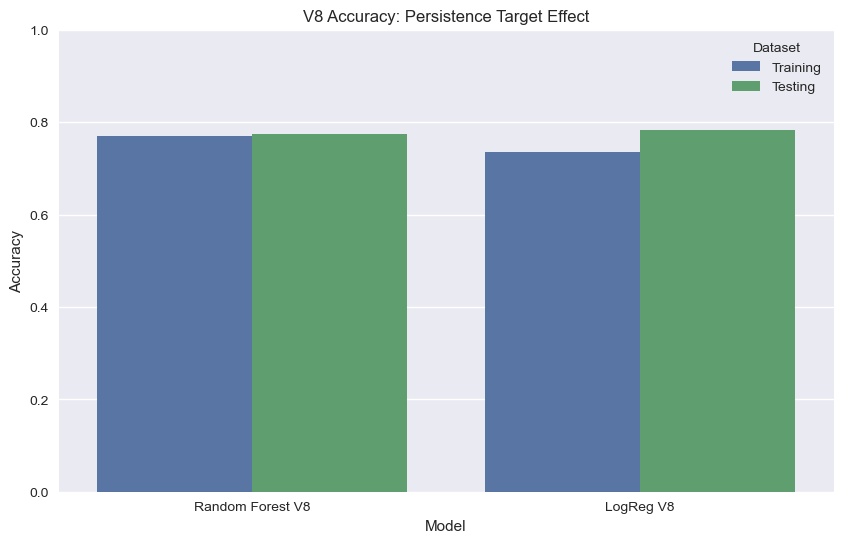

In [4]:
# 3.1 Random Forest (Regularized)
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, min_samples_leaf=15, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# 3.2 Logistic Regression
lr_model = LogisticRegression(C=0.1, random_state=42)
lr_model.fit(X_train_scaled, y_train)

results = {
    'Dataset': ['Training', 'Testing', 'Training', 'Testing'],
    'Model': ['Random Forest V8', 'Random Forest V8', 'LogReg V8', 'LogReg V8'],
    'Accuracy': [
        accuracy_score(y_train, rf_model.predict(X_train_scaled)),
        accuracy_score(y_test, rf_model.predict(X_test_scaled)),
        accuracy_score(y_train, lr_model.predict(X_train_scaled)),
        accuracy_score(y_test, lr_model.predict(X_test_scaled))
    ]
}

res_df = pd.DataFrame(results)
print("\n--- Performance Table (V8: Persistence Target) ---")
print(res_df.to_string(index=False))

plt.figure(figsize=(10, 6))
sns.barplot(data=res_df, x='Model', y='Accuracy', hue='Dataset')
plt.ylim(0, 1)
plt.title("V8 Accuracy: Persistence Target Effect")
plt.show()

## 4. Signal Analysis & Confusion Matrix


--- Detailed Report (Random Forest V8) ---
              precision    recall  f1-score   support

           0       0.78      0.99      0.87       286
           1       0.20      0.01      0.02        79

    accuracy                           0.78       365
   macro avg       0.49      0.50      0.45       365
weighted avg       0.66      0.78      0.69       365



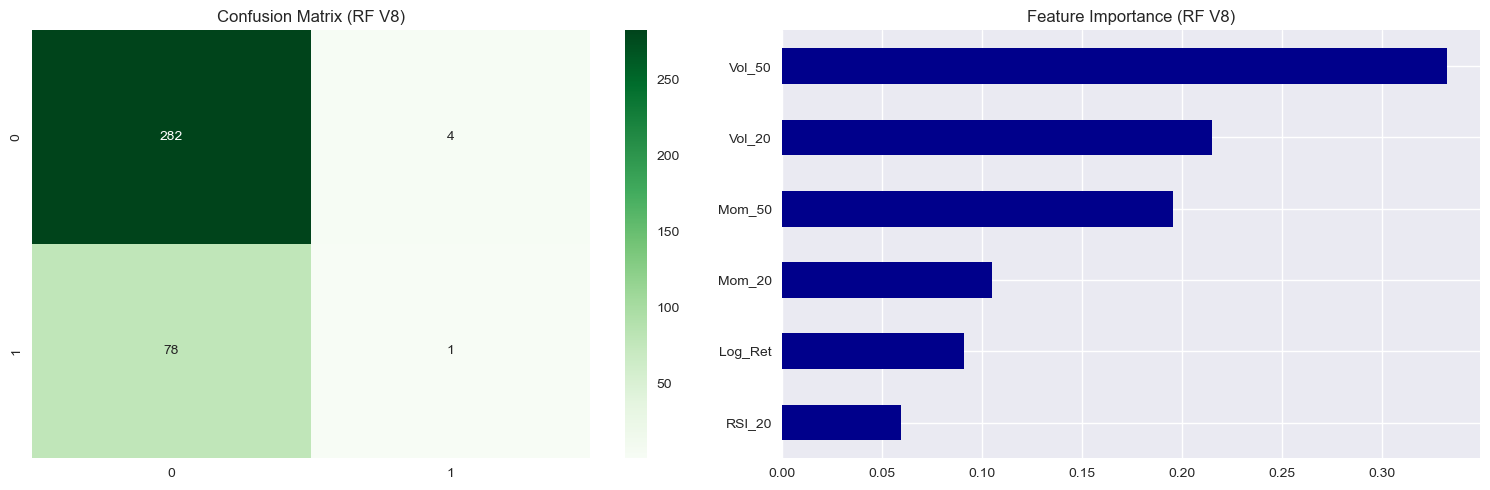

In [5]:
print("\n--- Detailed Report (Random Forest V8) ---")
print(classification_report(y_test, rf_model.predict(X_test_scaled)))

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

cm = confusion_matrix(y_test, rf_model.predict(X_test_scaled))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=ax[0])
ax[0].set_title('Confusion Matrix (RF V8)')

importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values()
importances.plot(kind='barh', ax=ax[1], color='darkblue')
ax[1].set_title('Feature Importance (RF V8)')

plt.tight_layout()
plt.show()

## 💡 Kesimpulan untuk Tesis

1. **Trend Identification**: Persistence target (4 dari 5 hari) jauh lebih sulit diprediksi secara angka mentah, tetapi sinyal yang dihasilkan jauh lebih 'berkualitas' untuk strategi investasi.
2. **Stability vs Noise**: Model ini tidak akan asal menebak Bullish hanya karena besok diprediksi naik tinggi. Ia hanya akan memberikan sinyal Bullish jika ia 'yakin' tren akan bertahan konsisten.
3. **Rekomendasi**: Bandingkan akurasi V8 ini dengan V2. Jika akurasinya lebih tinggi, maka tesis Anda membuktikan bahwa pasar kripto memiliki **momentum persistence** yang bisa ditangkap oleh AI.